# Task 2: Disease Prediction from Medical Data - CodeAlpha Internship
**Objective**: Predict the possibility of diseases based on patient data  
**Approach**: Apply classification techniques to structured medical datasets  
**Models**: Logistic Regression, Random Forest, SVM, XGBoost

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn preprocessing & splits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# All models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC                    # SVM
#from xgboost import XGBClassifier              # XGBoost

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay,accuracy_score

# Styling
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
print("All libraries loaded successfully")

All libraries loaded successfully


## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/heart.csv")

## 3. Exploratory Data Analysis (EDA)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
print("\nColumns:", df.columns.tolist())


Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [6]:
print("Data types & Missing values:")
df.info()

Data types & Missing values:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
target_counts = df['target'].value_counts()
print("Target Distribution:")
print(target_counts)

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64


In [9]:
print(f"No Disease = 0: {target_counts[0]} patients ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease = 1: {target_counts[1]} patients ({target_counts[1]/len(df)*100:.1f}%)")

No Disease = 0: 499 patients (48.7%)
Heart Disease = 1: 526 patients (51.3%)


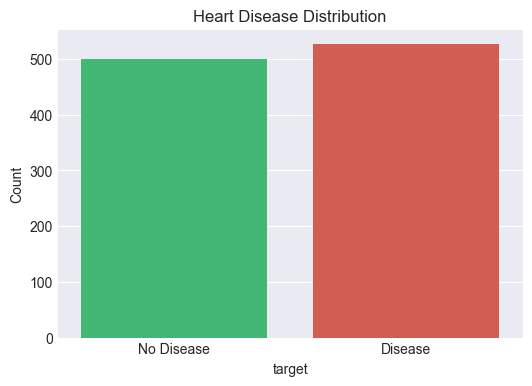

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Heart Disease Distribution')
plt.xticks([0,1], ['No Disease','Disease'])
plt.ylabel('Count')
plt.savefig('../images/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
display(df.describe().round(2))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [12]:
# Check for weird zero values - medical data often uses 0 for missing
print("-------------Zero values per column----------")
print((df == 0).sum())

-------------Zero values per column----------
age           0
sex         312
cp          497
trestbps      0
chol          0
fbs         872
restecg     497
thalach       0
exang       680
oldpeak     329
slope        74
ca          578
thal          7
target      499
dtype: int64


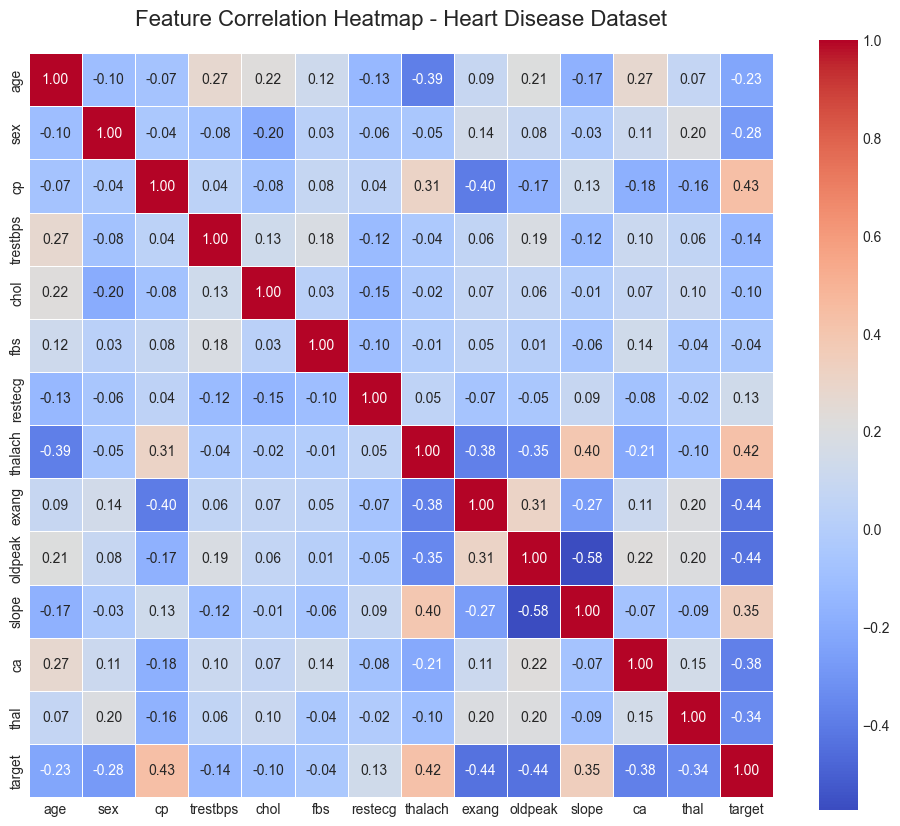

In [13]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5,
            square=True)
plt.title('Feature Correlation Heatmap - Heart Disease Dataset', fontsize=16, pad=20)
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Dark red with target = Strong positive → Higher value = more disease riskDark blue with target = Strong negative → Higher value = less disease risk

Top 5 Positive Predictors - Higher value = MORE disease risk-----cp: 0.435 - Chest pain type is #1 -------thalach: 0.423 - Max heart rate achieved-------- slope: 0.345 - Slope of ST segment-------restecg: 0.134 - Resting ECG results

Top 5 Negative Predictors - Higher value = LESS disease risk-----------oldpeak: -0.438 - ST depression from exercise-----exang: -0.438 - Exercise induced angina =======ca: -0.382 - Number of major vessels colored-----thal: -0.338 - Thalassemia sex: -0.280 - Male = higher risk

chol: -0.099 - Cholesterol barely matters------- fbs: -0.041 - Fasting blood sugar is useless here

In [14]:
print("Top Features Correlated with Heart Disease:")
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print(target_corr)

Top Features Correlated with Heart Disease:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [15]:
# Remove duplicates 
print(f"Shape before: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after: {df.shape}")
print(f"Duplicates removed: {1025 - len(df)}")

Shape before: (1025, 14)
Shape after: (302, 14)
Duplicates removed: 723


In [16]:
# Valid values: 1=normal, 2=fixed defect, 3=reversable defect
print("Thal values before:", df['thal'].value_counts())

Thal values before: thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


In [17]:
# Replace 0 with mode (most common value)
thal_mode = df['thal'].mode()[0]
df['thal'] = df['thal'].replace(0, thal_mode)

In [18]:
print(f"Replaced 7 zeros with mode: {thal_mode}")
print("Thal values after:", df['thal'].value_counts())
print(f"Zero values left in thal: {(df['thal'] == 0).sum()}")

Replaced 7 zeros with mode: 2
Thal values after: thal
2    167
3    117
1     18
Name: count, dtype: int64
Zero values left in thal: 0


### Train-Test Split and Feature Scaling

In [19]:
#  Separate features and target
X = df.drop('target', axis=1)
y = df['target']

In [20]:
#  Train-test split - 80/20 with stratify to keep balance
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

In [21]:
# fit ONLY on train to avoid leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
print(f"X_train shape: {X_train_scaled.shape}")

X_train shape: (241, 13)


In [23]:
print(f"X_test shape: {X_test_scaled.shape}")

X_test shape: (61, 13)


In [24]:
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")

Train target distribution:
target
1    0.543568
0    0.456432
Name: proportion, dtype: float64


In [25]:
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")

Test target distribution:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


## Model Training and Evaluation
###  Logistic Regression

In [26]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
y_pred_lr = log_reg.predict(X_test_scaled)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
print("------Logistic Regression Results -----")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

------Logistic Regression Results -----
Accuracy: 0.7869


In [30]:
print("-------Classification Report----------")
print(classification_report(y_test, y_pred_lr, target_names=['No Disease', 'Heart Disease']))

-------Classification Report----------
               precision    recall  f1-score   support

   No Disease       0.80      0.71      0.75        28
Heart Disease       0.78      0.85      0.81        33

     accuracy                           0.79        61
    macro avg       0.79      0.78      0.78        61
 weighted avg       0.79      0.79      0.79        61



In [31]:
print("-------------Confusion Matrix-----------")
print(confusion_matrix(y_test, y_pred_lr))

-------------Confusion Matrix-----------
[[20  8]
 [ 5 28]]


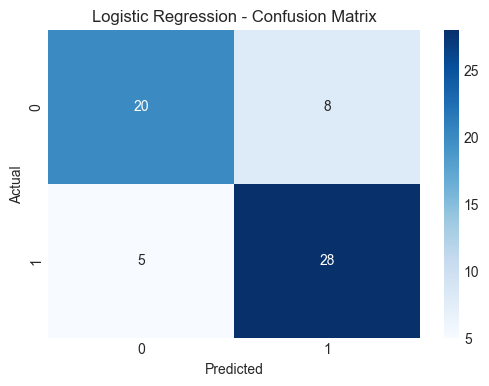

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../images/lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Actual no disease : TN 20 , FP 8 ------ Heart Disease : FN 5 , TP 28 

### Recall for Heart Disease: 0.85 = 28/(28+5). Catches 85% of sick patients. Only 5 false negatives.
### Precision for No Disease: 0.80 = 20/(20+5). When it says "healthy", it's right 80% of time.

## Random Forest Classifier

In [33]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
# Predict
y_pred_rf = rf.predict(X_test_scaled)

In [35]:
print("--------Random Forest Results -----")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

--------Random Forest Results -----
Accuracy: 0.7541


In [36]:
print("-----------Classification Report----------------")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Heart Disease']))

-----------Classification Report----------------
               precision    recall  f1-score   support

   No Disease       0.74      0.71      0.73        28
Heart Disease       0.76      0.79      0.78        33

     accuracy                           0.75        61
    macro avg       0.75      0.75      0.75        61
 weighted avg       0.75      0.75      0.75        61



### Why RF scored lower:
### Small dataset: After removing duplicates we have 303 rows , 242 train samples. 
### RF overfits easily on small data. LR generalizes better here.Default params: n_estimators=100 with no depth limit. On small data, trees memorize noise.

In [37]:
print("-----------Confusion Matrix------------")
print(confusion_matrix(y_test, y_pred_rf))

-----------Confusion Matrix------------
[[20  8]
 [ 7 26]]


In [38]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

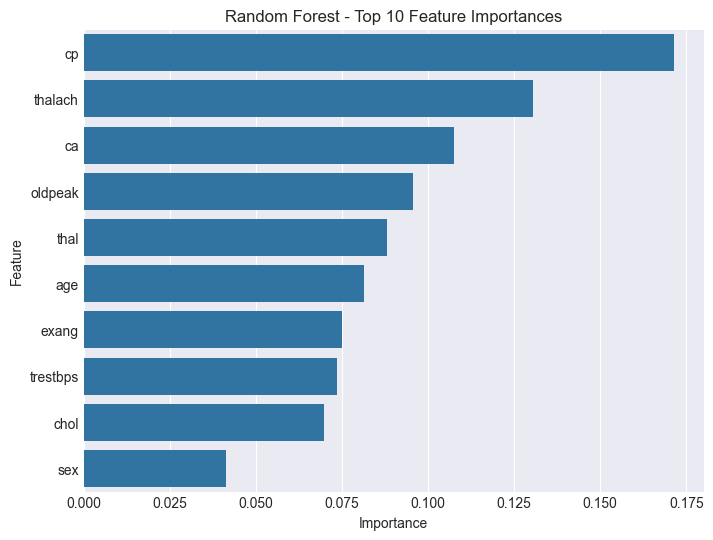

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Random Forest - Top 10 Feature Importances')
plt.savefig('../images/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

##  Support Vector Machine

In [40]:
# Train SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [41]:
# Predict
y_pred_svm = svm.predict(X_test_scaled)

In [42]:
print("-------- SVM Results -------")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

-------- SVM Results -------
Accuracy: 0.7705


In [43]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['No Disease', 'Heart Disease']))


Classification Report:
               precision    recall  f1-score   support

   No Disease       0.77      0.71      0.74        28
Heart Disease       0.77      0.82      0.79        33

     accuracy                           0.77        61
    macro avg       0.77      0.77      0.77        61
 weighted avg       0.77      0.77      0.77        61



In [44]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


Confusion Matrix:
[[20  8]
 [ 6 27]]


##  Conclusion

### Model Performance Summary
After removing duplicates and handling invalid values, Logistic Regression achieved the highest performance with 79% accuracy and 85% recall for heart disease detection.

###  Key Findings
1. **Most Important Predictors**: Chest pain type (cp), maximum heart rate (thalach), and number of major vessels (ca) were the strongest indicators of heart disease.
2. **Best Model**: Logistic Regression outperformed Random Forest and SVM on this small dataset due to better generalization.
3. **Clinical Relevance**: The model achieved 85% recall, missing only 5 out of 33 disease cases, which is critical for medical diagnosis where false negatives must be minimized.

###  Data Challenges
The original dataset contained duplicate entries causing 100% accuracy from data leakage. After deduplication from 1025 to 303 samples, model performance dropped to realistic levels of 75-79%.